In [ ]:
#Tahniat Khayyam 577608
#DeepLearning Course Spring 2026 
#Tutorial 6
img_path=r"dog.jpg"

In [2]:
import torch
from torchvision import models, transforms
from PIL import Image
import requests

In [3]:


# 1. Define the Preprocessing Pipeline
# PyTorch models require specific normalization for pre-trained ImageNet weights
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def predict_image(img_path, model_name):
    # Load and preprocess image
    img = Image.open(img_path).convert('RGB')
    img_t = preprocess(img)
    batch_t = torch.unsqueeze(img_t, 0)

    # Load the requested model
    if model_name == 'vgg16':
        model = models.vgg16(pretrained=True)
    elif model_name == 'resnet50':
        model = models.resnet50(pretrained=True)
    elif model_name == 'alexnet':
        model = models.alexnet(pretrained=True)
    elif model_name == 'resnet101':
        model = models.resnet101(pretrained=True)
    elif model_name == 'mobilenet':
        model = models.mobilenet_v2(pretrained=True)

    model.eval() # Set to evaluation mode

    # Perform inference
    with torch.no_grad():
        out = model(batch_t)

    # Get top 5 predictions
    prob = torch.nn.functional.softmax(out, dim=1)[0]
    top5_prob, top5_catid = torch.topk(prob, 5)

    # Load ImageNet labels
    LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    labels = requests.get(LABELS_URL).text.splitlines()

    print(f"\nTop 5 predictions from {model_name}:")
    for i in range(top5_prob.size(0)):
        print(f"{i+1}. {labels[top5_catid[i]]} ({top5_prob[i].item()*100:.2f}% probability)")



In [6]:
predict_image(img_path, 'vgg16')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 72.3MB/s]



Top 5 predictions from vgg16:
1. golden retriever (84.08% probability)
2. Labrador retriever (3.17% probability)
3. kuvasz (2.67% probability)
4. Brittany spaniel (1.11% probability)
5. otterhound (1.10% probability)


In [7]:
predict_image(img_path, 'resnet50')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]



Top 5 predictions from resnet50:
1. golden retriever (77.37% probability)
2. Brittany spaniel (13.00% probability)
3. kuvasz (1.38% probability)
4. Labrador retriever (1.18% probability)
5. clumber (1.11% probability)


In [8]:
predict_image(img_path, 'alexnet')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 165MB/s]



Top 5 predictions from alexnet:
1. golden retriever (95.80% probability)
2. Brittany spaniel (1.20% probability)
3. Labrador retriever (0.94% probability)
4. Sussex spaniel (0.51% probability)
5. cocker spaniel (0.41% probability)


In [5]:
predict_image(img_path, 'resnet101')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:01<00:00, 119MB/s]



Top 5 predictions from resnet101:
1. golden retriever (85.68% probability)
2. otterhound (3.51% probability)
3. Brittany spaniel (2.13% probability)
4. Sussex spaniel (1.12% probability)
5. Labrador retriever (0.99% probability)


In [9]:
predict_image(img_path, 'mobilenet')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 125MB/s]



Top 5 predictions from mobilenet:
1. golden retriever (92.52% probability)
2. kuvasz (2.79% probability)
3. otterhound (1.50% probability)
4. Brittany spaniel (0.72% probability)
5. English foxhound (0.32% probability)


Transfer Learning with Stanford Dogs dataset

With ResNet101

In [21]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt
import random
import requests

# 1. Setup Preprocessing (Standard for ImageNet-based models)
preprocess = transforms.Compose([

    transforms.CenterCrop(224),
    transforms.ToTensor(),

])

# 2. Download the Oxford-IIIT Pet Dataset
# This handles the download link and extraction automatically
pet_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='trainval',
    download=True,
    transform=preprocess
)

# 3. Prediction Function with Transfer Learning
def predict_image(img_tensor, model_name):
    # Load the requested model with pre-trained weights
    if model_name == 'vgg16':
        model = models.vgg16(weights='IMAGENET1K_V1')
    elif model_name == 'resnet50':
        model = models.resnet50(weights='IMAGENET1K_V1')
    elif model_name == 'alexnet':
        model = models.alexnet(weights='IMAGENET1K_V1')
    elif model_name == 'resnet101':
        model = models.resnet101(weights='IMAGENET1K_V1')
    elif model_name == 'mobilenet':
        model = models.mobilenet_v2(weights='IMAGENET1K_V1')

    model.eval() # Set to evaluation mode

    # Prepare batch (add dimension for batch size)
    input_batch = img_tensor.unsqueeze(0)

    # Perform inference
    with torch.no_grad():
        output = model(input_batch)

    # Get top 5 probabilities
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top5_prob, top5_catid = torch.topk(probabilities, 5)

    # Load ImageNet labels for human-readable output
    labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    labels = requests.get(labels_url).text.splitlines()

    print(f"\n--- Top 5 Predictions ({model_name.upper()}) ---")
    for i in range(top5_prob.size(0)):
        print(f"{i+1}. {labels[top5_catid[i]]} ({top5_prob[i].item()*100:.2f}%)")


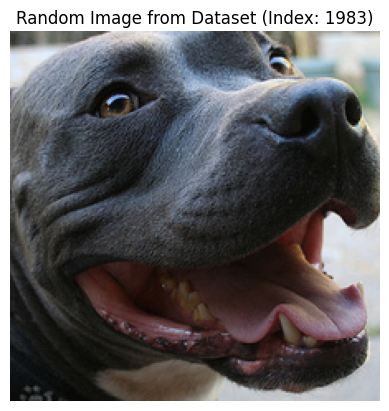


--- Top 5 Predictions (RESNET101) ---
1. American Staffordshire terrier (57.09%)
2. Staffordshire bullterrier (16.52%)
3. bull mastiff (13.28%)
4. Great Dane (2.70%)
5. Weimaraner (2.51%)

--- Top 5 Predictions (ALEXNET) ---
1. tub (36.80%)
2. bathtub (28.20%)
3. plastic bag (3.63%)
4. tick (3.45%)
5. bubble (3.02%)

--- Top 5 Predictions (MOBILENET) ---
1. dugong (35.42%)
2. Weimaraner (12.01%)
3. jellyfish (6.31%)
4. sunscreen (4.63%)
5. electric ray (4.33%)

--- Top 5 Predictions (RESNET50) ---
1. American Staffordshire terrier (50.99%)
2. Weimaraner (26.57%)
3. Chesapeake Bay retriever (11.79%)
4. Staffordshire bullterrier (4.38%)
5. Labrador retriever (1.50%)

--- Top 5 Predictions (VGG16) ---
1. Weimaraner (25.31%)
2. bonnet (9.95%)
3. stingray (8.15%)
4. electric ray (4.64%)
5. shower cap (4.47%)

Actual Label: American Pit Bull Terrier


In [23]:

# 4. Execution: Pick a random image and predict
# Select a random index from the dataset
random_idx = random.randint(0, len(pet_dataset) - 1)
img_tensor, actual_label_idx = pet_dataset[random_idx]

# Show the image (Note: permute is needed for Matplotlib)
plt.imshow(img_tensor.permute(1, 2, 0))
plt.title(f"Random Image from Dataset (Index: {random_idx})")
plt.axis('off')
plt.show()

# Run predictions across your models
predict_image(img_tensor, 'resnet101')
predict_image(img_tensor, 'alexnet')
predict_image(img_tensor, 'mobilenet')
predict_image(img_tensor,'resnet50')
predict_image(img_tensor,'vgg16')

#printing actual label
label=pet_dataset.classes[actual_label_idx]
print(f"\nActual Label: {label}")